In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.special as sp
import pytensor.tensor as pt
from pytensor.scalar.basic import UnaryScalarOp
from pytensor.tensor.elemwise import Elemwise
import pytensor.scalar as ps
import numpy as np
import pymc as pm
from IPython.display import display
import arviz as az

![Figura](https://raw.githubusercontent.com/fadelrio/Ingenieria/master/Taller%20de%20Se%C3%B1ales/notebooks/res/fig_tp11.png)

# Ley de Kirchhoff de corrientes

Como se conoce la tensión $V$ en $R_L$, se puede plantear el nodo A:

$$I_{ph} = I_d + I_p + I$$

Todas estas corrientes se pueden expresar en funcion de la tensión $V$, de la siguiente forma:

Corriente en la carga: $$I = \frac{V}{R_L}$$

Tensión en el diodo y $R_p$: $$V_d = V + I \cdot R_s = V \left( \frac{R_L + R_s}{R_L} \right)$$

Corriente en la resistencia en paralelo: $$I_p = \frac{V_d}{R_p} = \frac{V(R_L + R_s)}{R_p R_L}$$

Corriente en el diodo (Shockley): $$I_d = I_0 \left( e^{\frac{V(R_L + R_s)}{n V_T R_L}} - 1 \right)$$

Sustituyendo en la ecuación de nodos y agrupando términos con $V$, se puede llegar a la expresión final:
$$I_{ph} + I_0 = I_0 e^{\frac{V(R_L + R_s)}{n V_T R_L}} + V \left( \frac{R_L + R_s + R_p}{R_p R_L} \right)$$

# Tensión sobre la carga

Se define $\alpha = \frac{R_s + R_L}{n V_T R_L}$ y $\beta = \frac{R_L + R_s + R_p}{R_p R_L}$.

Reescribiendo la ecuación del inciso anterior como $I_{ph} + I_0 = I_e + V \cdot \beta$, donde $I_e = I_0 e^{\alpha V}$, se puede despejar $V$ en función de $I_e$:
$$V = \frac{(I_{ph} + I_0) - I_e}{\beta}$$

Del reemplazar esta expresión de $V$ en $I_e$ se obtiene:
$$I_e = I_0 e^{\frac{\alpha}{\beta}(I_{ph} + I_0)} \cdot e^{-\frac{\alpha}{\beta}I_e}$$

Multiplicando por $\frac{\alpha}{\beta} e^{\frac{\alpha}{\beta}I_e}$, se parametreiza de la forma $w e^w = z$:
$$\frac{\alpha}{\beta} I_e e^{\frac{\alpha}{\beta}I_e} = \frac{\alpha}{\beta} I_0 e^{\frac{\alpha}{\beta}(I_{ph} + I_0)}$$

Teniendo en cuenta que $w e^w = z \implies w = W(z)$, y reescribiendo $z = e^x$, se introduce $h(x) = W(e^x)$. Tomando el logaritmo natural al coeficiente, se puede definir $x$:
$$x = \ln\left(\frac{\alpha}{\beta} I_0\right) + \frac{\alpha}{\beta}(I_{ph} + I_0)$$

Entonces $\frac{\alpha}{\beta} I_e = h(x)$, lo que implica $I_e = \frac{\beta}{\alpha} h(x)$. Sustituyendo esto en la ecuación de $V$:
$$V = \frac{I_{ph} + I_0}{\beta} - \frac{1}{\alpha} h(x)$$

Finalmente, reemplazando $\alpha$ y $\beta$ por sus valores originales se puede obtener la expresión final:
$$V = (I_{ph} + I_0) \left( \frac{R_p R_L}{R_L + R_s + R_p} \right) - \left( \frac{n V_T R_L}{R_s + R_L} \right) h(x)$$

Donde la variable $x$ es:
$$x = \ln \left[ \frac{R_p(R_s + R_L)}{n V_T(R_L + R_s + R_p)} I_0 \right] + \frac{R_p(R_s + R_L)}{n V_T(R_L + R_s + R_p)} (I_{ph} + I_0)$$

# Derivada de  $\mathbf{h(x) = W(e^x)}$ respecto a $\mathbf{h(x)}$

Partiendo desde $z = W(z)e^{W(z)}$ y derivando respecto a $z$ se obtiene:
$$1 = W'(z)e^{W(z)} + W(z)e^{W(z)}W'(z)$$
$$1 = W'(z)e^{W(z)}(1 + W(z))$$

Despejando $W'(z)$ y sabiendo que de la definición original $e^{W(z)} = \frac{z}{W(z)}$:
$$W'(z) = \frac{1}{e^{W(z)}(1 + W(z))} = \frac{1}{\left(\frac{z}{W(z)}\right)(1 + W(z))} = \frac{W(z)}{z(1 + W(z))}$$

Se halla $h'(x)$ aplicando la regla de la cadena para $h(x) = W(e^x)$:
$$h'(x) = W'(e^x) \cdot e^x$$

Evaluando $W'(z)$ en $z = e^x$ y sustituyendo:
$$h'(x) = \left[ \frac{W(e^x)}{e^x(1 + W(e^x))} \right] \cdot e^x = \frac{W(e^x)}{1 + W(e^x)}$$

Finalmente, se expresa el resultado en términos de $h(x)$:
$$h'(x) = \frac{h(x)}{1 + h(x)}$$

In [3]:
url = "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/pv.csv"

# Descargar y cargar el CSV en un DataFrame
df = pd.read_csv(url)

# Mostrar las primeras filas
print(df.head())
print(df.info())


         RL         V
0  0.003334  0.004952
1  0.003815  0.000000
2  0.004296  0.000000
3  0.004777  0.003245
4  0.005258  0.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RL      500 non-null    float64
 1   V       500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB
None


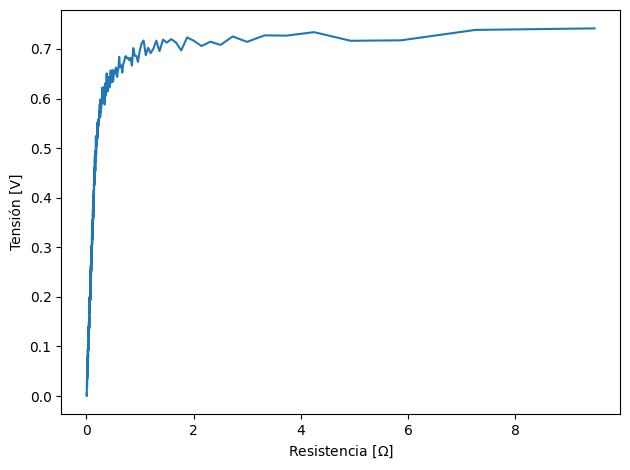

In [4]:
plt.figure()
plt.plot(df.RL, df.V)
plt.ylabel("Tensión [V]")
plt.xlabel(r"Resistencia [$\Omega$]")
plt.tight_layout()
plt.show()

# MCMC

Se utilizará un método de montecarlo por cadenas de markov para obtener la distribucion a posteriori de los parámetros que relacionan la tensión sobre la carga con la resistencia de esta.

Una cadena de Markov es una secuencia de variables aleatorias $\{\theta_t\}_{t∈\mathbb{N}}$ que cumple la propiedad de falta de memoria: la
distribución del próximo estado depende únicamente del estado actual, y no del pasado completo. Se buscará contruir una cadena de markov cuya distribucion estacionaria sea la distribucion a posteriori. Se deben cumplir ciertas condiciones:

- La transicion $\theta \rightarrow \theta ' $ debe poder ser alcanzada en una cantidad finita de pasos para todo $\theta$ y $\theta ' $.
- La transicion $\theta \rightarrow \theta$ debe tener probablidad positiva.
- El tiempo esperado para volver al estado actual es finito.

Se uitilaran algoritmos de muestereo para generar un proceso cuya secuencia de muestras sea ergódica. Para esto se definiran muestras de _tune_, que son las muestras necesarias para llegar al estado estacionario, muetras de _draw_, que son las muestras efectivas generadas. Por ultimo, esto se hará en multiples _chains_ para verificar los resultados de cada uno, ya que una disparidad en las cadenas demostrará que no se alcanzó el estado estacionario.

In [5]:
class custom_func(UnaryScalarOp):

    # h(x) = W(exp(x))
    def impl(self, x):
        return sp.lambertw(np.exp(x)).real

    # dh/dx = h/(1+h)
    def grad(self, x, dx):
        (x,) = x
        (dx,) = dx

        h = self(x)

        return [dx * h / (1 + h)]

In [6]:
lambert_exp = Elemwise(
    custom_func(ps.upgrade_to_float),
    name="lambert_exp"
)

In [7]:
def modelo_tension(RL, Iph, I0, Rs, Rp, n, VT):

    A = Rp * RL / (RL + Rs + Rp)

    B = n * VT * RL / (Rs + RL)

    C = Rp * (Rs + RL) / (n * VT * (RL + Rs + Rp))

    x = pt.log(C * I0) + C * (Iph + I0)

    return (Iph + I0) * A - B * lambert_exp(x)

In [8]:
RL_data = np.asarray(df.RL, dtype=float)
V_data = np.asarray(df.V, dtype=float)
VT = 0.0259

In [9]:
with pm.Model() as model:

    Iph = pm.Normal("Iph", mu=3, sigma=1)

    I0 = pm.LogNormal("I0", mu=-10, sigma=1)

    Rs = pm.HalfNormal("Rs", sigma=1)

    Rp = pm.HalfNormal("Rp", sigma=500)

    n = pm.Normal("n", mu=1.2, sigma=0.2)

    sigma = pm.HalfNormal("sigma", sigma=0.01)

    V_pred = modelo_tension(
        RL_data,
        Iph,
        I0,
        Rs,
        Rp,
        n,
        VT
    )

    pm.Normal(
        "V_obs",
        mu=V_pred,
        sigma=sigma,
        observed=V_data
    )

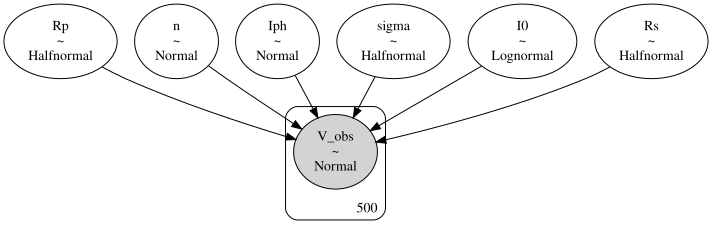

In [10]:
with model:
    graph = pm.model_to_graphviz(model)

display(graph)


Se buscará obtener un valor de ess_bulk mayor a 300, y un $\hat{R}$ menor a 1.01.

$\hat{R}$ es una medida de similitud de las distribuciones obtenidas en las cadenas, cuanto más cercano a 1 sea el valor, más parecidas son las distribuciones y se puede decir con mayor certeza que el algoritmo ha convergido.

ess_bulk indica la cantidad de muestras independientes que se obtuvieron de las cadenas.

In [ ]:
with model:
    trace = pm.sample(
        draws=2000,
        tune=700,
        chains=2,
        target_accept=0.95,
        random_seed=10072003
    )

Output()

In [ ]:
summary = az.summary(
    trace,
    var_names=["Iph", "I0", "Rs", "Rp", "n", "sigma"]
)

print(summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Iph,3.026,0.008,3.011,3.041,0.000,0.000,1596.0,1537.0,1.0
I0,0.000,0.000,0.000,0.000,0.000,0.000,1090.0,1673.0,1.0
Rs,0.040,0.002,0.036,0.043,0.000,0.000,1231.0,1860.0,1.0
Rp,451.974,308.009,16.018,999.164,6.299,5.431,1598.0,1131.0,1.0
n,1.850,0.077,1.705,1.991,0.002,0.001,1113.0,1558.0,1.0
sigma,0.010,0.000,0.009,0.011,0.000,0.000,2573.0,2399.0,1.0


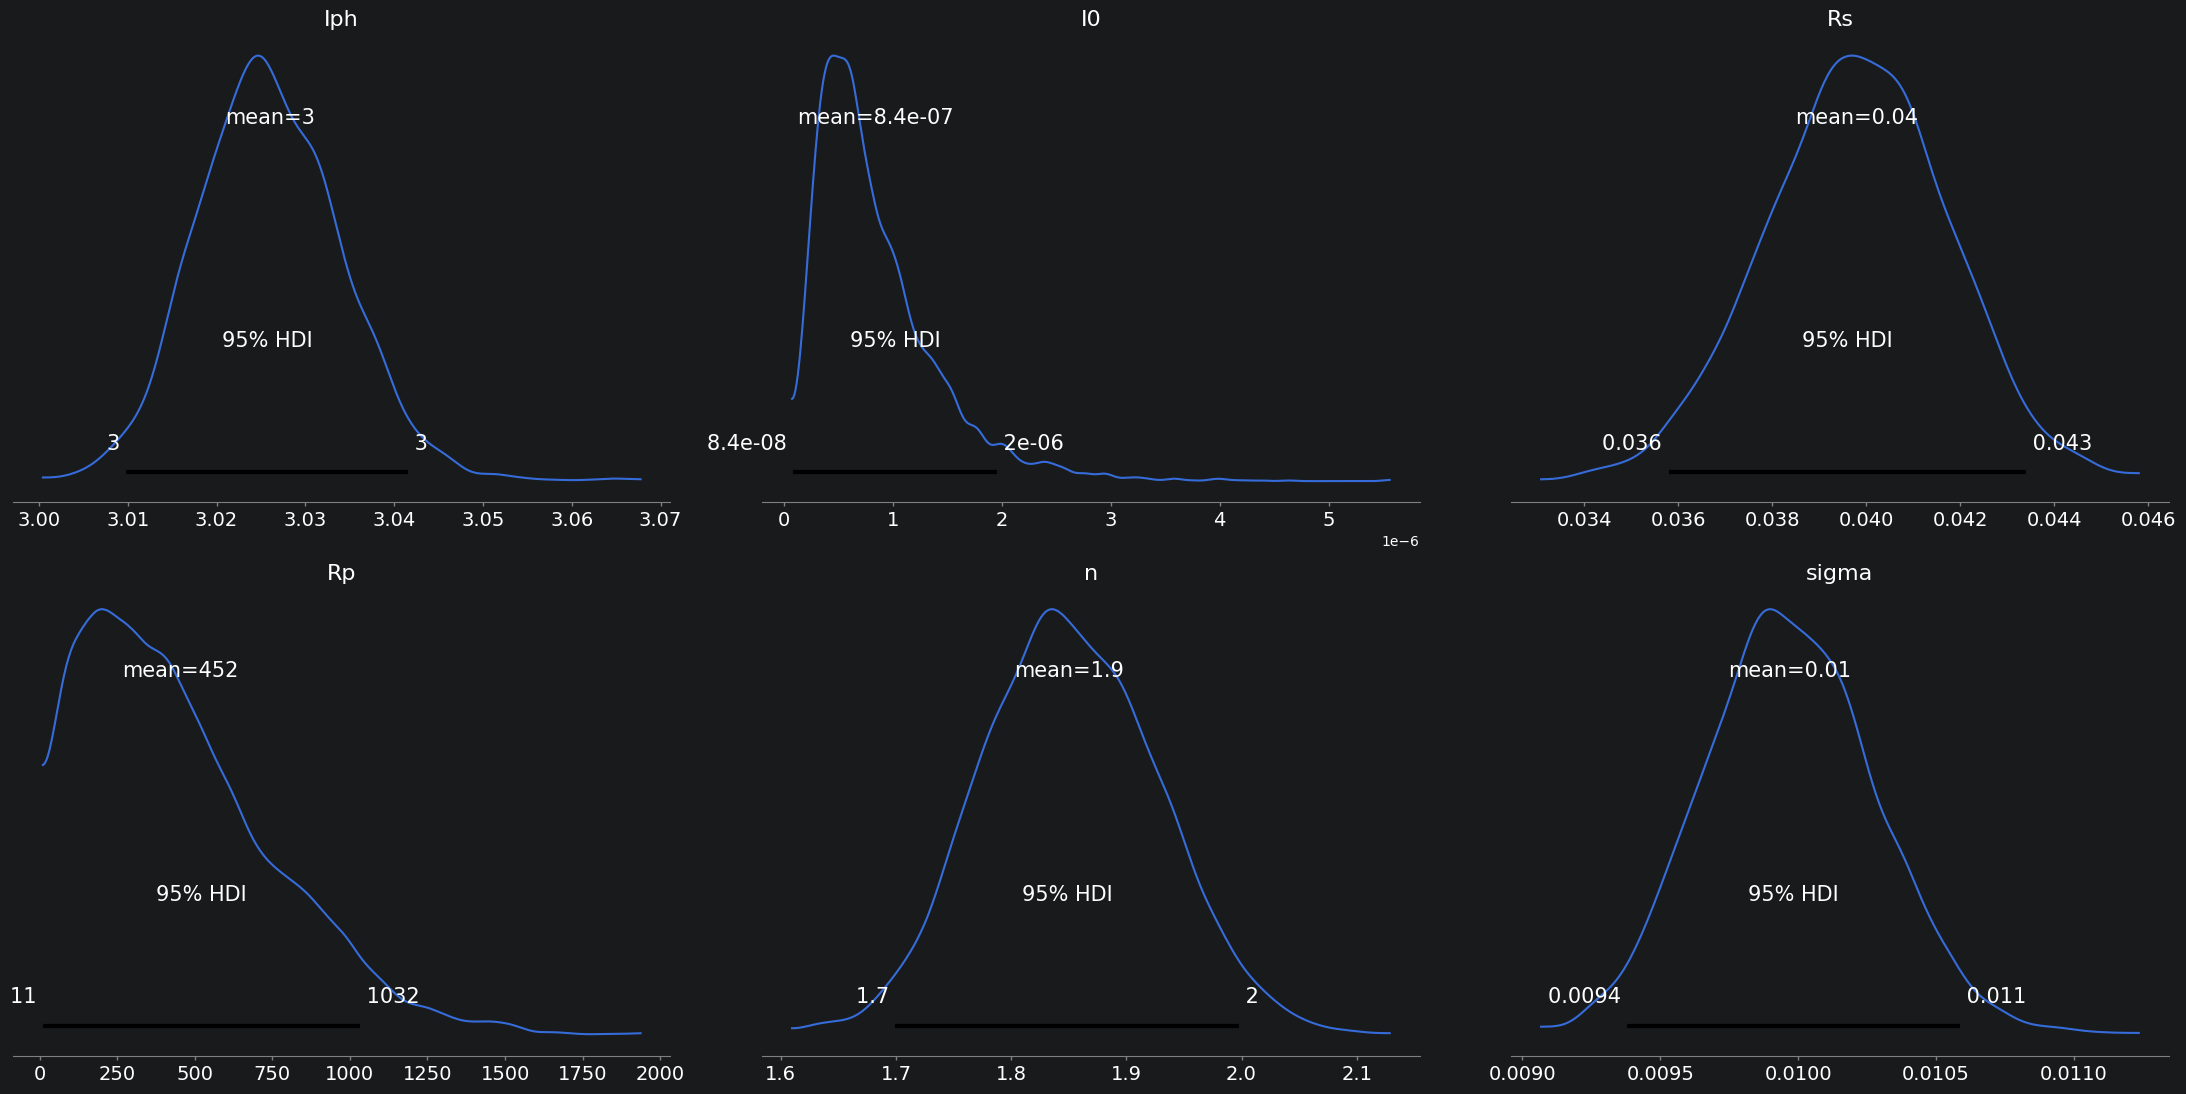

In [ ]:
az.plot_posterior(
    trace,
    var_names=["Iph", "I0", "Rs", "Rp", "n", "sigma"],
    point_estimate="mean",
    hdi_prob=0.95
)

plt.tight_layout()
plt.show()

In [ ]:
with model:
    posterior_predictive = pm.sample_posterior_predictive(
        trace,
        var_names=["V_obs"]
    )

Output()

In [ ]:
V_pred_mean = (
    posterior_predictive.posterior_predictive["V_obs"]
    .mean(dim=("chain", "draw"))
    .values
)

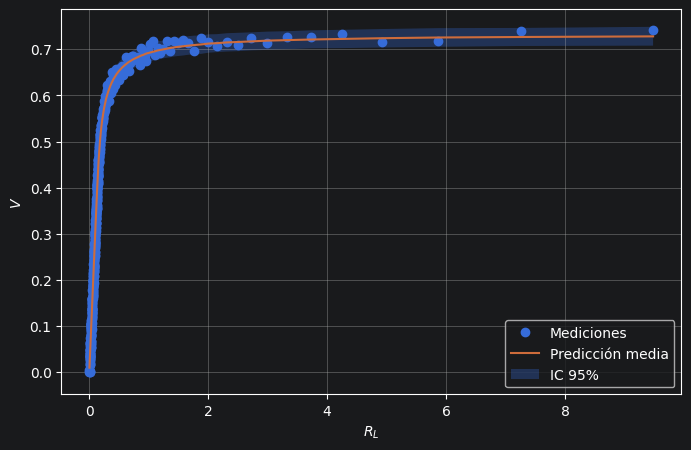

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    RL_data,
    V_data,
    "o",
    label="Mediciones"
)

plt.plot(
    RL_data,
    V_pred_mean,
    label="Predicción media"
)

plt.xlabel(r"$R_L$")
plt.ylabel(r"$V$")
plt.grid(True)
plt.legend()

plt.show()

Se puede observar como la prediccion obtenida ajusta de forma muy certera a los datos, esto da indicios de que las distribuciones a posteriori obtenidas para los paŕametros de la celda fotovoltaica son acertados, por lo menos con su media.